In [ ]:
# Temel kutuphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# On isleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Kumeleme algoritmalari
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Boyut indirgeme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Degerlendirme metrikleri
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Kütüphaneler başarıyla yüklendi.')

df = pd.read_csv('/content/ramen-ratings.csv')


Kütüphaneler başarıyla yüklendi.


In [ ]:
df.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


In [ ]:
df.describe()

,Review #
count,2580.000000
mean,1290.500000
std,744.926171
min,1.000000
25%,645.750000
50%,1290.500000
75%,1935.250000
max,2580.000000


In [ ]:
print('Sütun tipleri: ', df.dtypes)

Sütun tipleri:  Review #     int64
Brand       object
Variety     object
Style       object
Country     object
Stars       object
Top Ten     object
dtype: object


In [ ]:
#Kopyaladığımız veri seti üzeriden devam edelim
df_kopya = df.copy()

In [ ]:
#Veri setine bakalım
print('-' * 70)
print('Veri Seti Bilgileri')
print(f'Satır Sayısı: {df.shape[0]}')
print(f'Sütun Sayısı: {df.shape[1]}')
print()
print('-' * 70)
print('Eksik veri var mı? \n', df_kopya.isnull().sum())
print('-' * 70)
print('Toplam tekrar eden satır sayısı ne?', df_kopya.duplicated().sum())
print('-' * 70)

----------------------------------------------------------------------
Veri Seti Bilgileri
Satır Sayısı: 2580
Sütun Sayısı: 7

----------------------------------------------------------------------
Eksik veri var mı? 
 Review #       0
Brand          0
Variety        0
Style          2
Country        0
Stars          0
Top Ten     2539
dtype: int64
----------------------------------------------------------------------
Toplam tekrar eden satır sayısı ne? 0
----------------------------------------------------------------------


In [ ]:
#Eksik verileri tespit etmiştik
#Style ve Top Ten sütunlarındaki eksik verileri dolduralım

df_kopya['Style'] = df_kopya['Style'].fillna('Değerlendirilmemiş')
df_kopya['Top Ten'] = df_kopya['Top Ten'].fillna('Değerlendirilmemiş')

print("Boş değerler doldurulduktan sonra Style sütununda eksik veri sayısı nedir?\n", df_kopya['Style'].isnull().sum())
print("Boş değerler doldurulduktan sonra Top Ten sütununda eksik veri sayısı nedir?\n", df_kopya['Top Ten'].isnull().sum())



Boş değerler doldurulduktan sonra Style sütununda eksik veri sayısı nedir?
 0
Boş değerler doldurulduktan sonra Top Ten sütununda eksik veri sayısı nedir?
 0


In [ ]:
#Değişkenlerin kategorik dağılımlarını inceleyelim

print("Değişkenlerin Kategorik Dağılımı")
print('-' * 70)
cat_columns = ['Review #' , 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten']
for col in cat_columns:
  print(f'\n{'-' * 50}')
  print(f'{col.upper()}')
  print(f'{'-' * 50}')


  for val, cnt in df_kopya[col].value_counts().items():
    print(f"{'%-25s' % str(val)} : {cnt:5d} ({cnt/len(df)*100:5.2f}%)")

Değişkenlerin Kategorik Dağılımı
----------------------------------------------------------------------

--------------------------------------------------
REVIEW #
--------------------------------------------------
1                         :     1 ( 0.04%)
2580                      :     1 ( 0.04%)
2579                      :     1 ( 0.04%)
2578                      :     1 ( 0.04%)
17                        :     1 ( 0.04%)
18                        :     1 ( 0.04%)
19                        :     1 ( 0.04%)
20                        :     1 ( 0.04%)
21                        :     1 ( 0.04%)
22                        :     1 ( 0.04%)
23                        :     1 ( 0.04%)
24                        :     1 ( 0.04%)
25                        :     1 ( 0.04%)
26                        :     1 ( 0.04%)
27                        :     1 ( 0.04%)
28                        :     1 ( 0.04%)
29                        :     1 ( 0.04%)
30                        :     1 ( 0.04%)
31        

In [ ]:
#Sayısal değişken olan stars sütununun istatistiklerine bakalım

print("-" * 70)
print("Sayısal Değişken İstatistiği")
print("-" * 70)
num_cols = ['Stars']
print(df_kopya[num_cols].describe().to_string())

----------------------------------------------------------------------
Sayısal Değişken İstatistiği
----------------------------------------------------------------------
       Stars
count   2580
unique    51
top        4
freq     384


In [ ]:
#Veri Önişleme

# 'Stars' sütununu sayısal türe çevir. Dönüştürülemeyen değerleri NaN yapar.
df_kopya['Stars'] = pd.to_numeric(df_kopya['Stars'], errors='coerce')

# Sayısal sütunları seç
numeric_cols = df_kopya.select_dtypes(include=np.number).columns

# Sayısal sütunlardaki eksik değerleri sütun ortalaması ile doldur
imputer = SimpleImputer(strategy='mean')
df_kopya[numeric_cols] = imputer.fit_transform(df_kopya[numeric_cols])

# İşlenmiş DataFrame'i df_imputed olarak atayalım
df_imputed = df_kopya.copy()

print(f'Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}')
print(f'\nVeri seti boyutu: {df_imputed.shape}')

Eksik deger kaldi mi: 0

Veri seti boyutu: (2580, 7)


In [ ]:
#Standardizasyon

# Sadece sayısal sütunları seç
numeric_cols_for_scaling = df_imputed.select_dtypes(include=np.number).columns
X_numeric = df_imputed[numeric_cols_for_scaling]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)
X_scaled = pd.DataFrame(X_scaled, columns=X_numeric.columns, index = X_numeric.index)

print("Ölçeklendirilmiş Verinin ilk beş satırı: ")
print(X_scaled.head())

Ölçeklendirilmiş Verinin ilk beş satırı: 
   Review #     Stars
0  1.731380  0.093958
1  1.730037 -2.616622
2  1.728694 -1.384540
3  1.727352 -0.891708
4  1.726009  0.093958


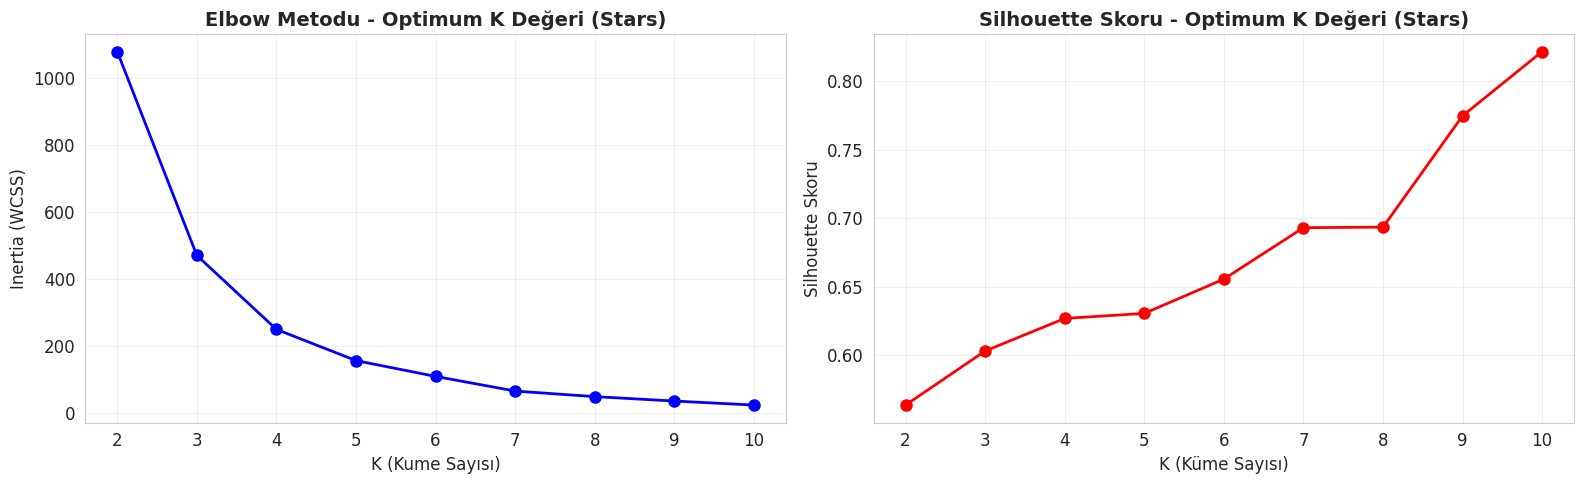

En iyi silhoutte skoru: 0.8215
Optimum K değeri: 10


In [ ]:
# Sadece 'Stars' sütununu alarak kümeleme yapalım
stars_scaled = X_scaled[['Stars']]

# Elbow metodu ile optimum K değeri
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Sadece Stars sütununu kullan
    labels = kmeans.fit_predict(stars_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(stars_scaled, labels))

# Görselleştirelim
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Değeri (Stars)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayısı)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Değeri (Stars)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Küme Sayısı)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhoutte skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K değeri: {optimal_k}')

In [ ]:
#Optimum K ile K-Means modelini eğitiyoruz
optimal_k = 3 #Elbow ve silhouette analizine göre optimal k değeri

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(stars_scaled)

print('K-Means Kümeleme Sonuçları:')
print(f'Küme sayısı: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(stars_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin İndeksi: {davies_bouldin_score(stars_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(stars_scaled, kmeans_labels):.4f}')
print(f'\nKüme dağılımı:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kümeleme Sonuçları:
Küme sayısı: 3
Silhouette Skoru: 0.6032
Davies-Bouldin İndeksi: 0.5062
Calinski-Harabasz Skoru: 5769.5790

Küme dağılımı:
0    1531
1     317
2     732
Name: count, dtype: int64


In [ ]:
#K-Means kümelerinin özetleri

df_imputed['KMeans_Cluster'] = kmeans_labels
cluster_summary = df_imputed.groupby('KMeans_Cluster')['Stars'].describe()
print("K-Means Küme Profilleri:")
print(cluster_summary)

K-Means Küme Profilleri:
                 count      mean       std   min   25%  50%   75%    max
KMeans_Cluster                                                          
0               1531.0  3.557341  0.380443  2.75  3.25  3.5  4.00  4.125
1                317.0  1.628785  0.784296  0.00  1.00  2.0  2.25  2.500
2                732.0  4.735587  0.307166  4.25  4.50  5.0  5.00  5.000


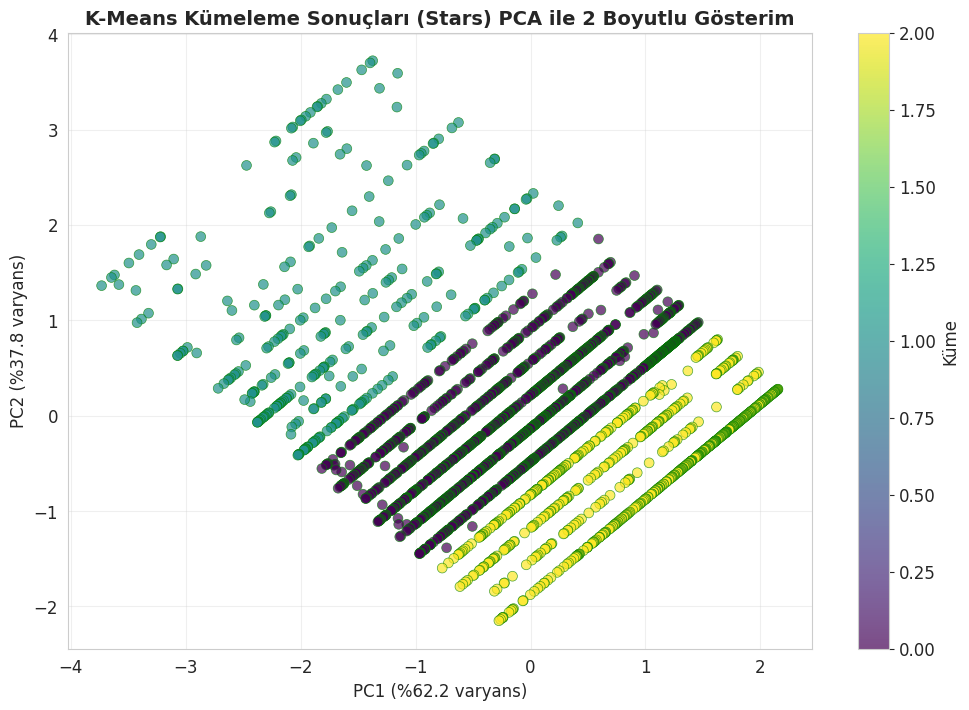

In [ ]:
# PCA ile K-Means Görselleştirmesi
# K-Means kümelemesi sadece 'Stars' sütunu üzerinde yapılmış olsa da,
# Görselleştirmeyi 'Review #' ve 'Stars' sütunlarının PCA ile indirgenmiş 2 boyutlu uzayında gösteriyoruz.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='green', linewidth=0.5)
plt.colorbar(scatter, label='Küme')
plt.title('K-Means Kümeleme Sonuçları (Stars) PCA ile 2 Boyutlu Gösterim', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

**HİYERARŞİK KÜMELEME (Agglomerative Clustering)**

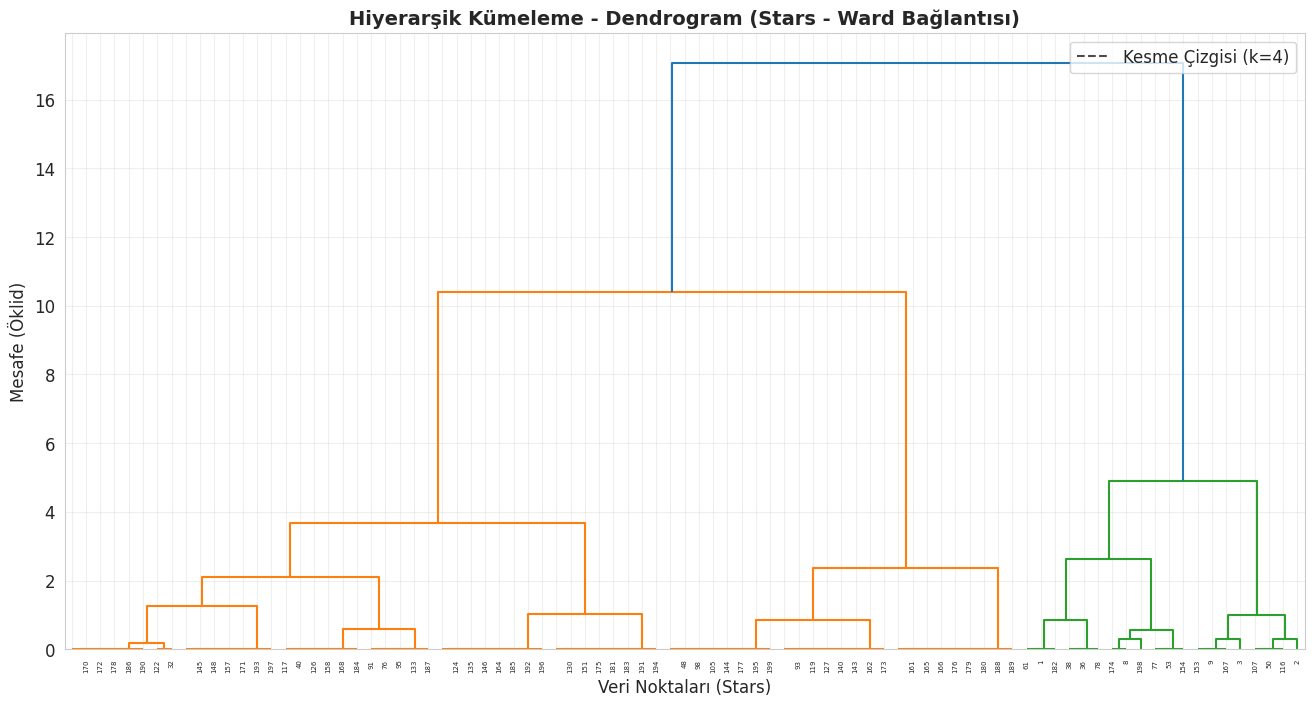

In [ ]:
# Dendrogram (Bağlantı yöntemi: ward) - Sadece 'Stars' sütunu için

plt.figure(figsize=(16, 8))
linked = linkage(stars_scaled[:200], method='ward')
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarşik Kümeleme - Dendrogram (Stars - Ward Bağlantısı)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktaları (Stars)', fontsize=12)
plt.ylabel('Mesafe (Öklid)', fontsize=12)
plt.axhline(y=30, color='black', linestyle='--', alpha=0.7, label='Kesme Çizgisi (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Agglomerative Clustering Modeli

agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(stars_scaled)

print('Hiyerarşik Kümeleme (Agglomerative) Sonuçları:')
print(f'Küme sayısı: {optimal_k}')
print(f'Bağlantı yöntemi: ward')
print(f'Silhouette Skoru: {silhouette_score(stars_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin İndeksi: {davies_bouldin_score(stars_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(stars_scaled, agg_labels):.4f}')
print(f'\nKüme dağılımı:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarşik Kümeleme (Agglomerative) Sonuçları:
Küme sayısı: 3
Bağlantı yöntemi: ward
Silhouette Skoru: 0.5912
Davies-Bouldin İndeksi: 0.4439
Calinski-Harabasz Skoru: 5010.1487

Küme dağılımı:
0    1768
1     227
2     585
Name: count, dtype: int64


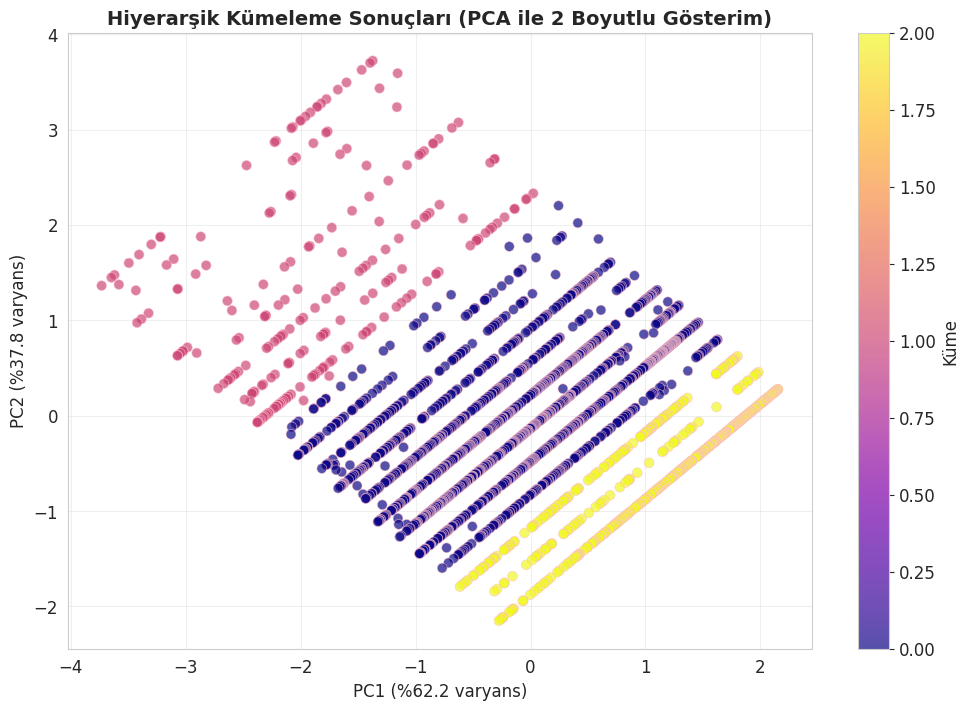

In [ ]:
# Hiyerarşik kümelerin görselleştirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='pink', linewidth=0.5)
plt.colorbar(scatter, label='Küme')
plt.title('Hiyerarşik Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**

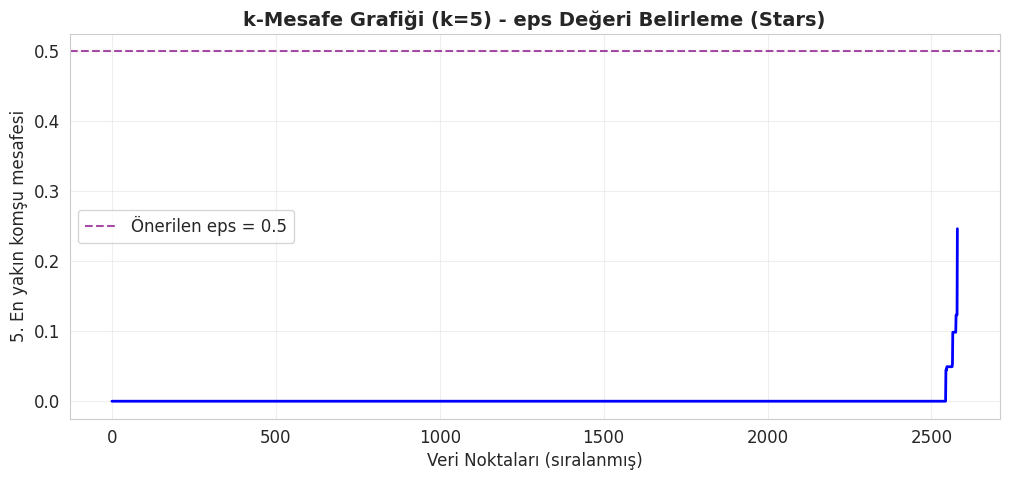

In [ ]:
#DBSCAN için eps değeri belirliyoruz
#K-distance grafiği


from sklearn.neighbors import NearestNeighbors

# Sadece 'Stars' sütununu kullanarak k-distance grafiği için NearestNeighbors uygulayalım
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(stars_scaled)
distances, indices = neighbors_fit.kneighbors(stars_scaled)

# 5. en yakın komşu mesafelerini sıralayalım
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafiği (k=5) - eps Değeri Belirleme (Stars)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktaları (sıralanmış)', fontsize=12)
plt.ylabel('5. En yakın komşu mesafesi', fontsize=12)
plt.axhline(y=0.5, color='purple', linestyle='--', alpha=0.7, label='Önerilen eps = 0.5') # Örnek bir değer, grafiğe göre ayarlanmalı
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# DBSCAN modeli
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(stars_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kümeleme Sonuçları:')
print(f'eps: 0.1, min_samples: 5')
print(f'Oluşan küme sayısı: {n_clusters_db}')
print(f'Gürültü (aykırı değer) sayısı: {n_noise}')
print(f'Gürültü oranı: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(stars_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin İndeksi: {davies_bouldin_score(stars_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(stars_scaled, dbscan_labels):.4f}')

print(f'\nKüme dağılımı:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Kümeleme Sonuçları:
eps: 0.1, min_samples: 5
Oluşan küme sayısı: 16
Gürültü (aykırı değer) sayısı: 3
Gürültü oranı: 0.12%
Silhouette Skoru: 0.6058
Davies-Bouldin İndeksi: 1.5363
Calinski-Harabasz Skoru: 3257.1467

Küme dağılımı:
-1        3
 0     1136
 1       29
 2       23
 3       64
 4      393
 5       11
 6       67
 7      386
 8      147
 9      135
 10      37
 11      70
 12      27
 13      14
 14      28
 15      10
Name: count, dtype: int64


In [ ]:
#DBSCAN kümelerinin görselleştirilmesi

